# Applied Deep Learning 2026 - "Exercise 0" - Introduction to Colab and some useful python skills

The excercises in this seminar are designed to work well in the Google Colab environments. You are free to run them on your local computer or another platform of your choice of course.

As first step in *every* exercise, create a copy of every notebook for yourself with "File -> Save a copy in Drive".

When you execute the first code cell in the notebooks of the exercises, Colab will ask you, whether this is safe. You can happily click "Run anyway" because you trust your lecturers of course ;)

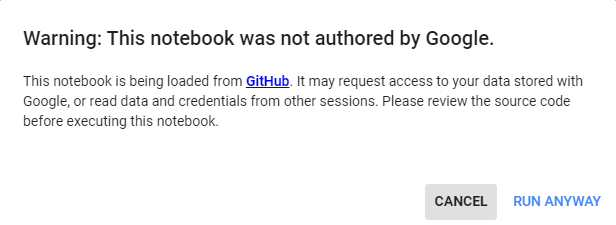

Google Colab essentiall works exactly like a Jupyter Notebook, which probably some of you are already familiar with. You can write and execute Python code interactively in every cell. The results are kept in memory until you restart the environment. Many Python packages like `numpy` or `scipy` are already preinstalled:

In [2]:
import numpy as np

x = np.linspace(0, 2*np.pi, 100) # create 100 linearly spaced numbers from 0 to 2*pi
y = np.sin(x) # compute the sine of those values

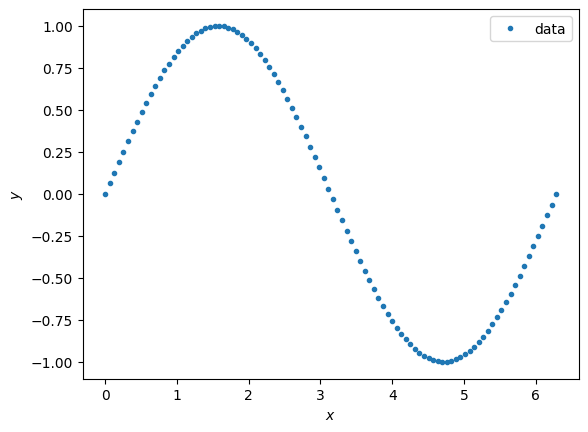

In [7]:
import matplotlib.pyplot as plt

plt.plot(x, y, '.', label='data')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend(loc='best'); # remove the `;` to see what changes
# you do not need to execute plt.show() in notebooks, the plot should appear anyway.

### Excersice 0: Hints
If you put the cursor inside of the brackets of a function, what happens if you hit `Shift+Tab` and then type anything (like a space or comma)? What about `Ctrl + Space`?

In [ ]:
np.mean(x)
np.mean(y)

np.float64(-1.2441300819921116e-17)

# Python packages used throughout the course

The most important Python packages, besides the machine learning libraries we will use ([`scikit-learn`](https://scikit-learn.org/stable/) and [`tensorflow`/`keras`](https://www.tensorflow.org/api_docs)), are certainly [`numpy`](https://numpy.org/doc/stable/contents.html), [`matplotlib`](https://matplotlib.org/stable/index.html) and [`pandas`](https://pandas.pydata.org/docs/index.html). Additionally, [`seaborn`](https://seaborn.pydata.org/) is a very use- and powerful visualization library.

# <a href=https://numpy.org><img src="https://numpy.org/images/logo.svg" width=50 align=center>numpy</a> refresher
If you do not already know, you will learn that the world of machine learning is full of vectors and matrices. In Python, `numpy` is the tool of choice to handle those.


In [9]:
vec = np.array([1,2,3,4,5,6])
print(vec)


[1 2 3 4 5 6]


In [ ]:
print('Shape of vec:', vec.shape)
print('Size of vec:', vec.size)
print('Dimension of vec:', vec.ndim)
#calling the attributes of the vector.

Shape of vec: (6,)
Size of vec: 6
Dimension of vec: 1


In machine learning frameworks it is common, that both the design matrix `X` (the data we want to use for training) and the target vector `y` (the labels or whatever we want to predict as goal of the training) are expected in the form `SxF` matrix (S,F) where `S` are the samples and `F` are the features.

In many cases, especially the target `y` has the shape like the vector we just created `(S,)`, in our case `(6,)`. This means, as you can see from the output of `vec.ndim`, that the vector is one-dimensional. There are two commonly used ways to change this to match the expected form for machine learning libraries:

In [ ]:
# reshape the existing vector into a SxF matrix
y = vec.reshape(6, 1)
print('y:', y)
print('Shape of y:', y.shape)
print('Size of y:', y.size)
print('Dimension of y:', y.ndim)

y: [[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
Shape of y: (6, 1)
Size of y: 6
Dimension of y: 2


In [ ]:
# create a new dimension to transform the vector into a matrix
y = vec[:, np.newaxis]
print('y:', y)
print('Shape of y:', y.shape)
print('Size of y:', y.size)
print('Dimension of y:', y.ndim)

y: [[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
Shape of y: (6, 1)
Size of y: 6
Dimension of y: 2


### Exercise 1: Row or column vector?

A common task in the background for machine learning are vector and matrix multiplications. Inspect the following commands. Which ones work, which ones give errors? If there is an error, why does it occur? If it works, what do they compute? What is a row vector, what a column vector in numpy? And what is the difference between those two anyway?

- `a = vec.reshape(-1, 1)`
- `b = vec.reshape(1, -1)`
- `c = vec.reshape(2, 3)`
- `d = vec.reshape(-1, 3)`
- `d = vec.reshape(-1, -1)`
- `e = vec[..., np.newaxis]`
- `f = c[:, np.newaxis]`
- `g = c[np.newaxis, :, :]`
- `h = c[np.newaxis, ...]`
- `i = np.dot(vec, vec)`
- `j = vec @ vec`
- `k = vec.T`
- `l = a.T`
- `m = np.dot(a, vec)`
- `n = c @ d`
- `o = c.T @ d`
- `p = c @ d.T`
- `q = c @ d.T @ c`
-` r = np.dot(c, d.T)`
- `s = np.matmul(c, d.T)`
- `t = np.dot(c, 4)`
- `u = np.dot(4, c)`
- `v = 4*c`


In [ ]:

a = vec.reshape(-1, 1)
print(a)

#this is a column vector with order (6,1)

[[1]
 [2]
 [3]
 [4]
 [5]
 [6]]


In [ ]:
b = vec.reshape(1, -1)
print(b)

#this is a row vector with order (1,6)

[[1 2 3 4 5 6]]


In [ ]:
c = vec.reshape(2, 3)
print(c)
#this is (2,3) matrix
print("dim of c is", c.ndim)
print("shape of c is", c.shape)
print('Size of c:', c.size)

[[1 2 3]
 [4 5 6]]
dim of c is 2
shape of c is (2, 3)
Size of c: 6


In [ ]:
d = vec.reshape(-1, 3)
print(d)
#this is also (2,3) matrix and d = vec.reshape(-1, -1) gives error as -1 is allowed only once.

[[1 2 3]
 [4 5 6]]


In [ ]:
e = vec[..., np.newaxis]
print(e)
#(6,1) column vector/matrix

[[1]
 [2]
 [3]
 [4]
 [5]
 [6]]


In [ ]:
f = c[:, np.newaxis]
print(f)
print("dim of f is", f.ndim)
print("shape of f is", f.shape)
print('Size of f:', f.size)
#(2,1,3), turned c into 3D vector


[[[1 2 3]]

 [[4 5 6]]]
dim of f is 3
shape of f is (2, 1, 3)
Size of f: 6


In [ ]:
g = c[np.newaxis, :, :]
print(g)
print("dim of g is", g.ndim)
print("shape of g is", g.shape)
print('Size of g:', g.size)
#(1,2,3), turned c into 3D vector

[[[1 2 3]
  [4 5 6]]]
dim of g is 3
shape of g is (1, 2, 3)
Size of g: 6


In [ ]:
h = c[np.newaxis, ...]
i = np.dot(vec, vec)
print(h)
print("i is:",i)
#h same as g (1,2,3) and i has dot product of two vectors, and is valid as two vectors have same order, compatible for dot product.

[[[1 2 3]
  [4 5 6]]]
i is: 91


In [ ]:
j = vec @ vec
print(j)
#same dot product, order of two vectors are compatible.

91


In [ ]:
k = vec.T
print("k is:",k)
print("vec is ", vec)
#transpose of vector. It does nothing as order before was (6,) and still (6,) after transpose. what can go wrong with it? haha

k is: [1 2 3 4 5 6]
vec is  [1 2 3 4 5 6]


In [ ]:
l = a.T
print(l) # transpose of a column matrix gives a row matrix.


[[1 2 3 4 5 6]]


In [ ]:
m = np.dot(a, vec)
print(m)
#a is a vector with order (6,1), while vec is (6,), shape mismatch. numpy expects the number of columns of first vector must equal number of rows of second matrix or vector for a valid scalar product.

ValueError: shapes (6,1) and (6,) not aligned: 1 (dim 1) != 6 (dim 0)

In [ ]:
n = c @ d
print(n)
#same reason as with m. incompatible shapes

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

In [ ]:
o = c.T @ d
print(o)
#shape is compatible. (3,2) @ (2,3) turning into (3,3) matrix

[[17 22 27]
 [22 29 36]
 [27 36 45]]


In [ ]:
p = c @ d.T
print(p)
#same reason as for o

[[14 32]
 [32 77]]


In [ ]:
q = c @ d.T @ c
r = np.dot(c, d.T)
print(q)
print(r)
#compatible based on above already stated logic for sclar products in numpy

[[142 188 234]
 [340 449 558]]
[[14 32]
 [32 77]]


In [ ]:
s = np.matmul(c, d.T)
print(s)
#same as with r, compatible matrix multiplication as well.

[[14 32]
 [32 77]]


In [ ]:

t = np.dot(c, 4)
print(t)

[[ 4  8 12]
 [16 20 24]]


In [ ]:
u = np.dot(4, c)
print(u)
#just multiplication with scalar, applies element-wise
#same for v=4*c

[[ 4  8 12]
 [16 20 24]]


## Excercise 2: Creating arrays

There are many ways to create arrays in numpy. Find out what the following do, what arguments they take and create some arrays with them:
- `np.zeros( ... )`
- `np.zeros_like( ... )`
- `np.ones( ... )`
- `np.ones_like( ... )`
- `np.eye( ... )`
- `np.linspace( ... )`
- `np.logspace( ... )`
- `np.arange( ... )`

In [ ]:
z_1= np.zeros((2,3)) #creates an numpy array with said order
print(z_1)

[[0. 0. 0.]
 [0. 0. 0.]]


In [ ]:
z_2=np.zeros_like(c) #creates a numpy array of zeroes but with same shape as c.
print(z_2)

[[0 0 0]
 [0 0 0]]


In [ ]:
z_3=np.ones((2,3)) #creates an numpy array with said order and entries are all 1.
print(z_3)

[[1. 1. 1.]
 [1. 1. 1.]]


In [ ]:
z_4=np.ones_like(e) #creates a numpy array of ones but with same shape as e.
print(z_4)


[[1]
 [1]
 [1]
 [1]
 [1]
 [1]]


In [ ]:
z_5=np.eye(3)
print(z_5) #creates an identity numpy array with said order_square matrix is understood.

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [ ]:
z_6=np.linspace(0,1,6) #6 evenly spaced numbers between the said interval.
print(z_6)

[0.  0.2 0.4 0.6 0.8 1. ]


In [ ]:
z_7=np.logspace(0,2,7)
print(z_7) #7 evely spaced numbers in base 10

[  1.           2.15443469   4.64158883  10.          21.5443469
  46.41588834 100.        ]


In [ ]:
z_8=np.arange(0,11,2) #arrange numbers between 0 and 10, in intervals of 2, excluding 11.
print(z_8)

[ 0  2  4  6  8 10]


## Exercise 3: Indexing and masking

You will in many cases not want to use all values from an array/vector/matrix. To select only some of them, you need to find a way to adress only those values.
1. Create a matrix using the command `mat = np.arange(105).reshape(3, 5, 7)`. Describe the result. How many dimensions does it have, what is its shape, what is its minimum and maximum value.
2. Run the following commands and inspect the results. What do the commands do, how do they work? If there are errors, why do they occur? It can be helpful to display the matrix `mat` as well to see what's going on:
  - `mat[2, 1, 6]`
  - `mat[:, 0, 0]`
  - `mat[:, 2, 4]`
  - `mat[:, 4, :]`
  - `mat[:, :, 7]`
  - `mat[..., 5]`
  - `mat[ mat > 25 ]`
  - `mat[ mat > 25 ].shape`
  - `mat[ (mat > 25) & (mat < 50) ]`
  - `mat[ (mat > 25) and (mat < 50) ]`
  - `mat[ (mat < 10) | (mat > 90) ]`
  - `np.where( mat > 100 )`
  - `np.where( mat < 50, 0, mat)`
  - `np.where( mat < 50, 0, 1)`
  - `mat [ mat < 50 ] = -1`
  - `mat [ np.where(mat < 50) ] = -1`



In [ ]:
mat = np.arange(105).reshape(3, 5, 7)
print(mat)
print("dim of mat is", mat.ndim)
print("shape of mat is", mat.shape)
print("min of mat is", mat.min())
print("max of mat is", mat.max())
#The result has 7 columns, 5 rows and 3 dimensions. arrange fucntion generated a matrix from 0 to 104, with 1 unit increments, which is default increment.
#np.arange(105) creates a 1D array with numbers from 0 to 104. and reshape(3, 5, 7) transforms this 1D array into a 3-dimensional array with the following structure:

[[[  0   1   2   3   4   5   6]
  [  7   8   9  10  11  12  13]
  [ 14  15  16  17  18  19  20]
  [ 21  22  23  24  25  26  27]
  [ 28  29  30  31  32  33  34]]

 [[ 35  36  37  38  39  40  41]
  [ 42  43  44  45  46  47  48]
  [ 49  50  51  52  53  54  55]
  [ 56  57  58  59  60  61  62]
  [ 63  64  65  66  67  68  69]]

 [[ 70  71  72  73  74  75  76]
  [ 77  78  79  80  81  82  83]
  [ 84  85  86  87  88  89  90]
  [ 91  92  93  94  95  96  97]
  [ 98  99 100 101 102 103 104]]]
dim of mat is 3
shape of mat is (3, 5, 7)
min of mat is 0
max of mat is 104


In [ ]:
y_1=mat[2,1,6] # single number of said slicing/location from mat matrix above. index 2 for dimension, means it takes last block/dimension and, takes out the 2nd row(index 1) and 7th column (index 6) , which is element 83.
print(y_1)


83


In [ ]:
y_2= mat[:,0,0] # takes out first element of (index 0) of each dimension
print(y_2)

[ 0 35 70]


In [ ]:
y_3=mat[:,2,4] # shape (3,) and same rule applies as said above. element of row 3rd and 5th column from each dimension cosnidering 1 as starting point. indices in numpy starts from 0 so adjust accordingly.
print(y_3)

[18 53 88]


In [ ]:
y_4=mat[:,4,:] # shape (3,7), slice out the 5th row from each dimension, all columns included.
print(y_4)

[[ 28  29  30  31  32  33  34]
 [ 63  64  65  66  67  68  69]
 [ 98  99 100 101 102 103 104]]


In [ ]:
mat[:,:,7] # ERROR (index 7 out of bounds) as maximum index is 6 for columns.

IndexError: index 7 is out of bounds for axis 2 with size 7

In [ ]:
y_5=mat[...,5] # same as mat[:,:,5] → (3,5), same logic, ... used when no cutting done one other arguments.
print(y_5)

[[  5  12  19  26  33]
 [ 40  47  54  61  68]
 [ 75  82  89  96 103]]


In [ ]:
mat[mat > 25] # all values > 25 (1D result)
mat[mat > 25].shape # number of such elements

mat[(mat > 25) & (mat < 50)] # correct
mat[(mat > 25) and (mat < 50)] # error as Python for And operation expects single True or false values, but here we are having an entire array of booleans, for which & operation is suitable, which do element-wise logical operation.

mat[(mat < 10) | (mat > 90)] # union condition

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
mat[(mat > 25) & (mat < 50)] #gives back all those numbers that satisfies the logical operation.

array([26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42,
       43, 44, 45, 46, 47, 48, 49])

In [ ]:
np.where(mat > 100) # returns a tuple with entries being the indices of the entries satsifying the condition, each array for each dimension.
np.where(mat < 50, 0, mat) # replace values if condition satified, with zero otherwise stays unchanged.

np.where(mat < 50, 0, 1) # binary mask, same situation as above but for false situation, the replacment is 1, instead of unchanged/original value.


mat[mat < 50] = -1 #all elements asigned new value of -1, where condition is true.
mat[np.where(mat < 50)] = -1 # same thing

## Exercise 4: Random numbers and statistics

Numpy also has many functions for random number generation and statistics.
1. Look up the following functions and experiment with them to see how they work:
  - `np.random.uniform( ... )`
  - `np.random.normal( ... )`
  - `np.random.poisson( ... )`
  - `np.random.choice( ... )`
  - `np.random.shuffle( ... )`

2. More tasks with random numbers:
  - what is wrong with this: `a = np.random.shuffle(b)`
  - look up the function `plt.hist( ... )` and show histograms of a Gaussian and a normal distribution. What can you do with the parameters `range`, `bins`, `alpha`, `density`, `histtype`, `stacked`?
  - create a matrix `A` of shape (5, 4, 3, 2, 1) of Gaussian distributed values
  - what does `A.mean()` do? What does `A.mean(axis=(1,3,2))` do?
  - Does `A.std()` compute a sample or population standard deviation? What is the difference between them?
  - create another matrix `B = np.ones(shape=(6, 8, 10))`. Execute the following: `B_rebin = B.reshape(3, 2, 4, 2, 5, 2).mean(axis=(1, 3, 5))`. What is the result? What happend here? In what real situations would you use `mean` here, when `sum`?


In [ ]:
u_1=np.random.uniform(0,1,10) #This is the NumPy function used to draw samples from a uniform distribution.0 is lower boundary of number, 1 is the maximum number and 10 shows the size of the numbers taken from uniform distribution.
u_2=np.random.normal(0,1,10) #it takes from normal distribution
u_3=np.random.poisson(3,10) #this takes from poison distribution
u_4=np.random.choice([1,2,3], size=5) #random selection of numbers from mentioned set with number of elements being 5.
u_5=np.random.shuffle(u_2) # modifies vec in place and returns none.
print("u_1 is:",u_1)
print("u_2 is:",u_2)
print("u_3 is:",u_3)
print("u_4 is:",u_4)
print("u_5 is:",u_5)


u_1 is: [0.54947517 0.68440354 0.25046178 0.74941666 0.89565277 0.68744387
 0.53429809 0.73888849 0.60637189 0.82901517]
u_2 is: [ 0.42808011  0.80413406 -0.1198464  -0.69273503 -0.23422514  1.12223553
  0.46903589  0.98020296  1.4118984  -0.67395998]
u_3 is: [4 2 3 4 5 3 3 4 5 4]
u_4 is: [3 3 1 3 3]
u_5 is: None


In [ ]:
a = np.random.shuffle(b) #nothing wrong with it. that is how it is suppose to work.


print(a)



None


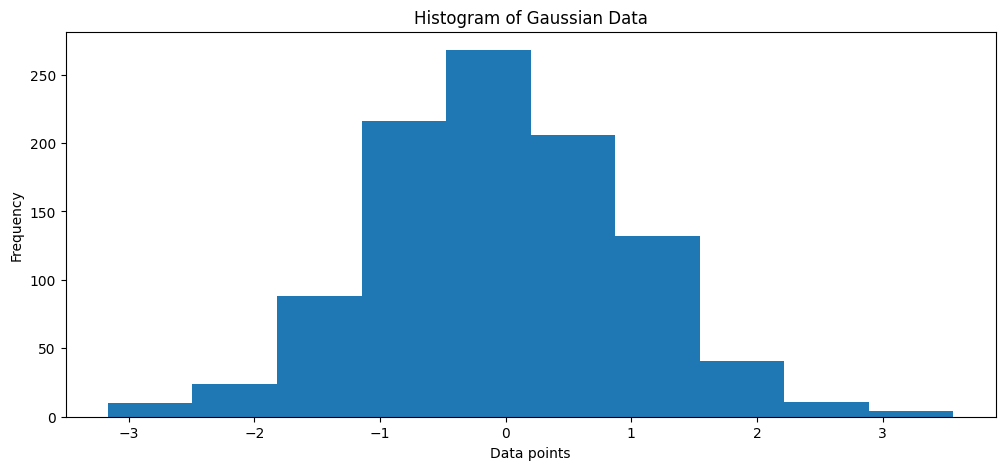

In [ ]:
#the plt.hist() function is used to plot histograms. A histogram is a representation of the distribution of numerical data.
# Generate Gaussian (normal) distributed data
gaussian_data = np.random.normal(loc=0, scale=1, size=1000)

# Generate Uniform distributed data
uniform_data = np.random.uniform(low=-3, high=3, size=1000)

# Basic histogram of Gaussian data
plt.figure(figsize=(12, 5))
plt.hist(gaussian_data)
plt.title('Histogram of Gaussian Data')
plt.xlabel('Data points')
plt.ylabel('Frequency')
plt.show()

#bins: Defines the number of equal-width bins in the range.
#range: The lower and upper range of the bins. If not provided, min and max of the data are used.
#density: If set it to True, the integral of the histogram will sum to 1 (pdf).
#alpha: controls the transparency of the histogram bars (ranges from 0 for fully transparent to 1 for fully opaque).
#histtype: The type of histogram to draw. Can be 'bar' (default), barstacked, step, or stepfilled.
#stacked: If set it to True and when multiple data sets are provided, they are stacked on top of each other. This parameter only works if histtype='bar' or histtype='barstacked'

#they are employed in next section

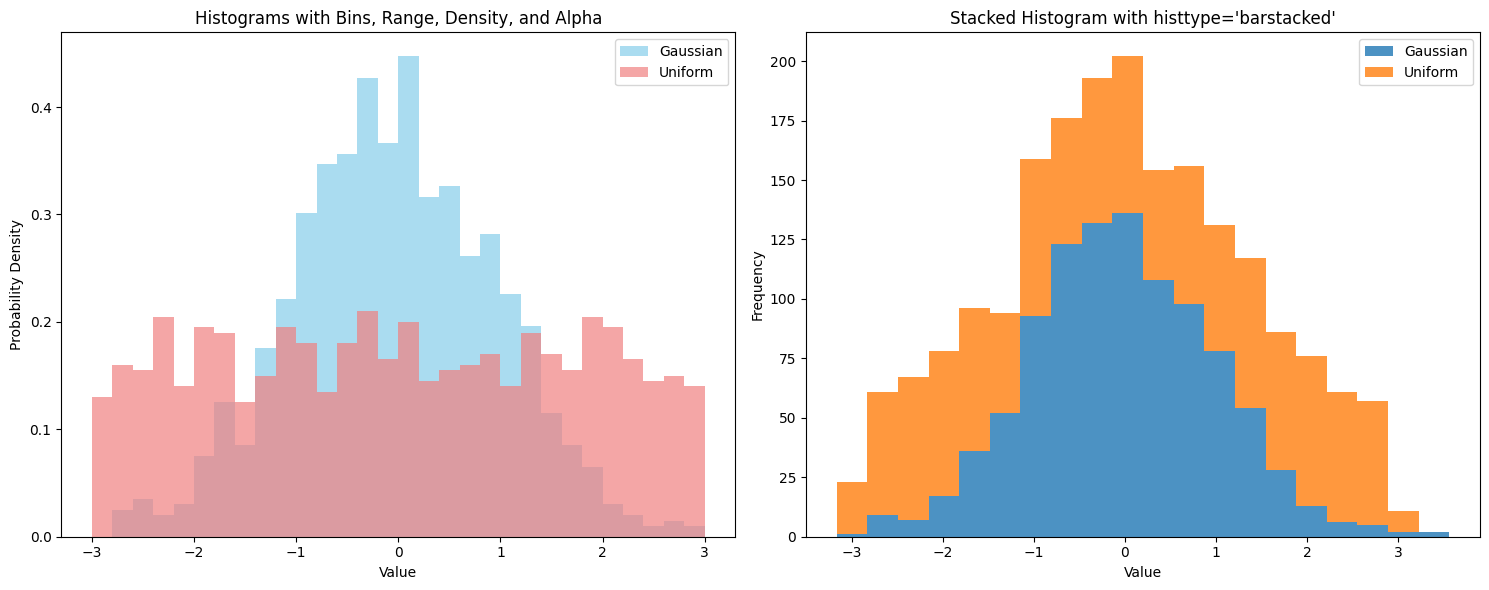

In [ ]:
# Demonstrate parameters
plt.figure(figsize=(15, 6))

# Histogram with custom values for bins, range, and density
plt.subplot(1, 2, 1)
plt.hist(gaussian_data, bins=30, range=(-3, 3), density=True, alpha=0.7, color='skyblue', label='Gaussian')
plt.hist(uniform_data, bins=30, range=(-3, 3), density=True, alpha=0.7, color='lightcoral', label='Uniform')
plt.title('Histograms with Bins, Range, Density, and Alpha')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.legend()

# Histogram with different histtype and stacked option
plt.subplot(1, 2, 2)
plt.hist([gaussian_data, uniform_data], bins=20, histtype='barstacked', stacked=True, alpha=0.8, label=['Gaussian', 'Uniform'])
plt.title('Stacked Histogram with histtype=\'barstacked\'')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Create a matrix A with Gaussian distributed values
A = np.random.normal(loc=0, scale=1, size=(5, 4, 3, 2, 1))

print("Shape of matrix A:", A.shape)
print("Matrix A (first few elements):\n", A[:2, :2, :2, :, :]) # Print a subset for readability

Shape of matrix A: (5, 4, 3, 2, 1)
Matrix A (first few elements):
 [[[[[-0.56081943]
    [-0.02938224]]

   [[ 0.2189229 ]
    [ 0.56329556]]]


  [[[ 0.46371553]
    [-0.39036488]]

   [[-0.06377717]
    [ 1.64539957]]]]



 [[[[ 0.64021483]
    [ 1.40416938]]

   [[ 1.17821594]
    [ 0.06714198]]]


  [[[-0.52987871]
    [-1.87460585]]

   [[-0.84616458]
    [-0.28174945]]]]]


In [ ]:
A.mean() # mean of all elements


np.float64(0.022405285411192025)

In [ ]:
A.mean(axis=(1,3,2)) # reduces those axes, calculates mean along specified axes

array([[ 0.23905241],
       [ 0.06319772],
       [ 0.04934461],
       [-0.06353982],
       [-0.1760285 ]])

In [ ]:
B = np.ones((6,8,10)) #creates a numpy array with 1's and said shape.

print(B.shape)
print(B)

(6, 8, 10)
[[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1

In [ ]:
B_rebin = B.reshape(3,2,4,2,5,2).mean(axis=(1,3,5))
print(B_rebin)
#reshaping from previous three dimensional shape to this new 6 dimensional shape, with same number of elements as before., and mean is calculated along said axes.
#sum is to sum up all values, while mean means sum over all values and dividing the sum by total number of values. They are used based upon what is needed.

[[[1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]]]


## <a href=https://pandas.pydata.org/><img src=https://pandas.pydata.org/docs/_static/pandas.svg align=center width=150></a> Pandas refresher

From the [pandas documentation](https://pandas.pydata.org/docs/getting_started/index.html):

### What kind of data does pandas handle?
When working with tabular data, such as data stored in spreadsheets or databases, pandas is the right tool for you. pandas will help you to explore, clean and process your data. In pandas, a data table is called a DataFrame.

<img src=https://pandas.pydata.org/docs/_images/01_table_dataframe.svg align=center width=300>

The pandas documentation is *that* good, that rewriting it would be pointless.

### Exercise 5: 10 minutes to pandas

To get warm with pandas, you should work your way through [this excellent quick start](https://pandas.pydata.org/docs/user_guide/10min.html#min) before you answer the following questions:
- what is a DataFrame?
- what is a Series?
- How is a Series/ DataFrame different from numpy arrays?
- How do you get numpy arrays from DataFrames?
- What do you need `.loc( ... )` for?
- What does `groupby` do? Find a real-world scenario where this might be very useful. Can you think of a potential application in machine learning?
- There are preinstalled data samples on the virtual machines running this Colab notebook. Use pandas `read_csv` to load the file `"sample_data/california_housing_train.csv"`. What do you think does this dataset describe? Look it up on the internet.
  - How many entries does the table have? How many columns? Are there missing values?
  - what are the min, max, mean and std dev of each column?
  - Create a scatterplot of `median_house_value` against `median_income`
  - Create a new column containing `total_rooms/population`.


In [ ]:
#Dataframe is a two-dimensional labeled data. unlike simple numpy arrays, it contains columns, rows and also name associated to each column and array.
#A series is a 1Dlabelled array or single column.
#numpy arrays are just numbers with no labels. While dataframe and series have a label associated with them. dataframes are makes dealing real datasets easier.
#we can get numpy arrays from dataframes using following command. df.to_numpy() or df.values
#.loc is used for label based indexing, like df.loc[row_label, column_name]. for example, df.loc[0, "median_income"]
#df.groupby splits the data into groups and applies operations. like, df.groupby("ocean_proximity".meam())

In [ ]:
!ls sample_data

anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


In [ ]:
import pandas as pd
# space for solutions

<Axes: xlabel='median_income', ylabel='median_house_value'>

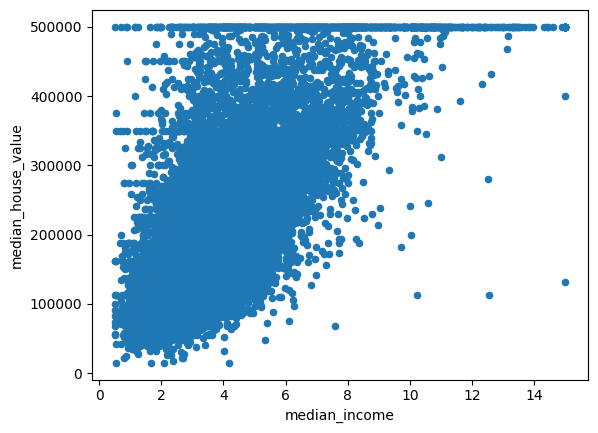

In [ ]:
df = pd.read_csv("sample_data/california_housing_train.csv")

df.shape
df.isnull().sum()
df.describe()

# scatter
df.plot.scatter(x="median_income", y="median_house_value")


In [ ]:
#we can see positive correlation. and also a horizontal cutoff, no house has value greater than a certain capped value.

In [ ]:
# new column
df["rooms_per_person"] = df["total_rooms"] / df["population"]
df.corr()["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.691871
rooms_per_person,0.206969
total_rooms,0.130991
housing_median_age,0.106758
households,0.061031
total_bedrooms,0.045783
population,-0.027850
longitude,-0.044982
latitude,-0.144917


# <a href=https://seaborn.pydata.org/><img src=https://seaborn.pydata.org/_static/logo-wide-lightbg.svg width=200 align=center></a> Seaborn - just a word on it

Seaborn simply makes quite nice plots. You should check out [their documentation](https://seaborn.pydata.org/). This is one example plot:

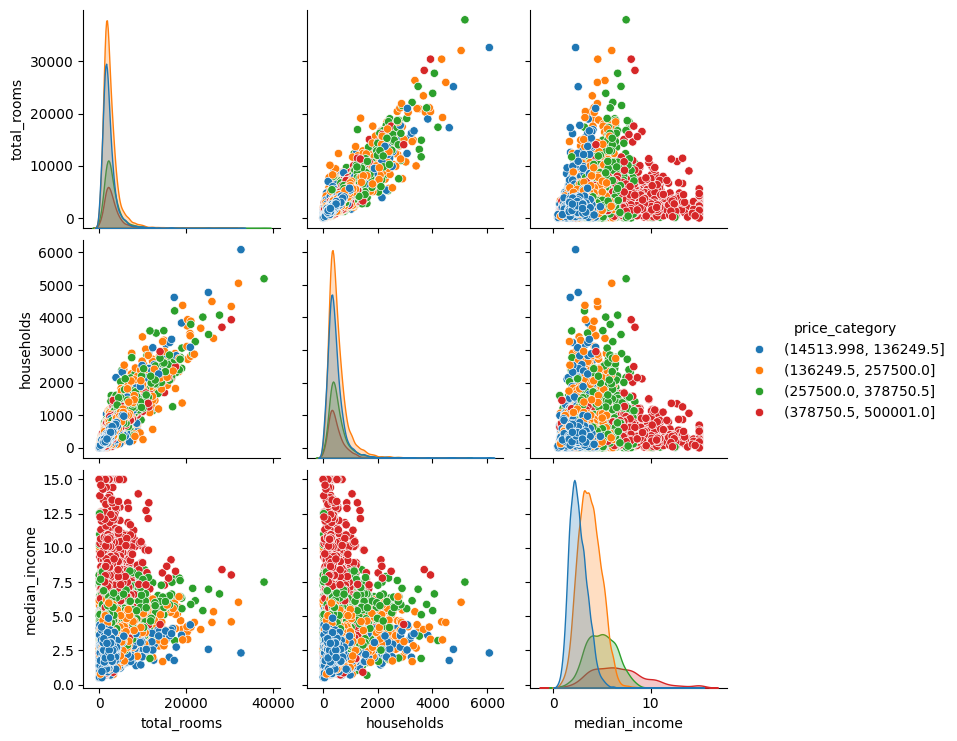

In [ ]:
import seaborn as sns
# read the csv we used before
data = pd.read_csv("sample_data/california_housing_train.csv")
# we create a new category feature dividing the house value in 4 ranges
data["price_category"] = pd.cut(data["median_house_value"], 4)
# the actual plot
sns.pairplot(data, vars=["total_rooms", "households", "median_income"], hue="price_category")

# K-Nearest Neighbors

## Excercise 6: Perform a classification using K-nearest neighbors classifier discussed in the lecture.

http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [ ]:
# we load the training data from the local virtual machine as well and get a numpy array from it
mnist_train = pd.read_csv("sample_data/mnist_train_small.csv", header=None ).to_numpy()
# the first entry is the digit, the rest of the array contains the pixel values
digits_train = mnist_train[:,0]
images_train = mnist_train[:,1:]
print(digits_train.shape)
print(images_train.shape)

(20000,)
(20000, 784)


This is a 6


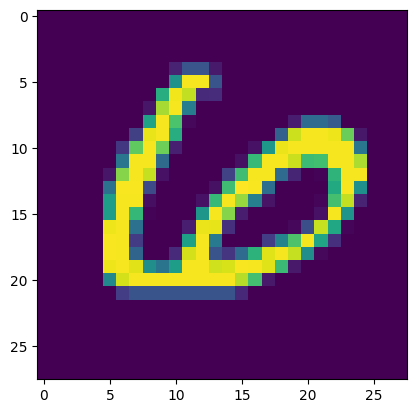

In [ ]:
# the images are 28x28 but we will use the flattened array for training because KNN can only handle tabular data
plt.imshow(images_train[0].reshape(28,28));
print(f"This is a {digits_train[0]}")

In [ ]:
# we train on some data and then we test on some other data, where would be the joke otherwise?
mnist_test = pd.read_csv("sample_data/mnist_test.csv", header=None ).to_numpy()
digits_test = mnist_test[:,0]
images_test = mnist_test[:,1:]

In [ ]:
# import the classifier
from sklearn.neighbors import KNeighborsClassifier

# we use 7 next neighbors (this is rather much)
kn = KNeighborsClassifier(n_neighbors=7)

# for now, we will only use 100 training samples to keep the runtime low
N_samples = 100
X_train = images_train[:N_samples]
y_train = digits_train[:N_samples]
# this trains the KNN classifier. We pass the images and the digits as design matrix and target vector
kn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

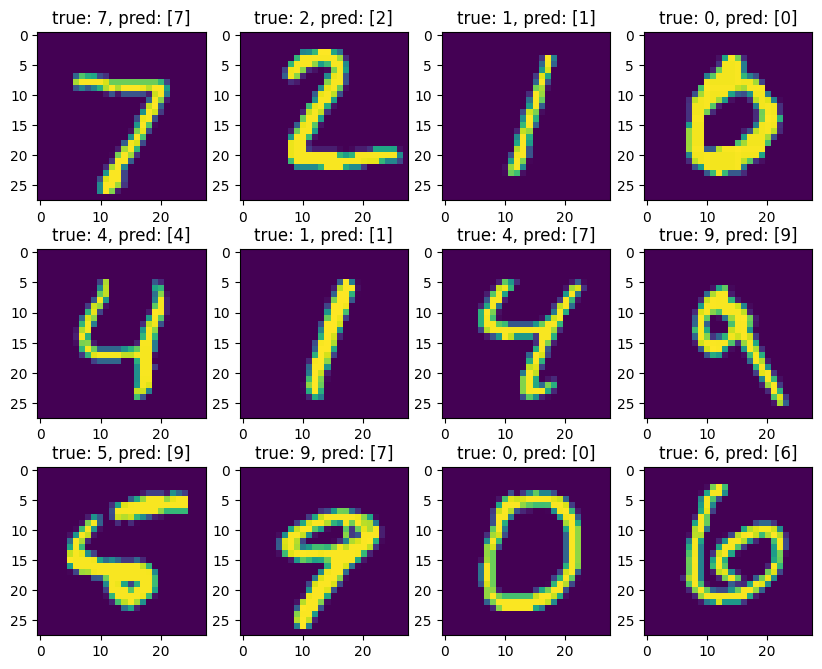

In [ ]:
rows    = 3
columns = 4
f, axes = plt.subplots(rows, columns, figsize=(10,8))

idx = 0
for r in range(rows):
  for c in range(columns):
      img        = images_test[idx].reshape(1, -1) # the shape needs to be (1, features)
      digit_true = digits_test[idx]
      digit_pred = kn.predict(img)
      axes[r, c].imshow(img.reshape(28,28))
      axes[r, c].set_title(f"true: {digit_true}, pred: {digit_pred}")
      idx += 1

# Exercise 7 - The actual tasks:
- Predict the digits for the whole training and test data set
- Compute the accuracy for both training and test predictions. How much difference is there?
- Plot some examples of misclassified digits.
- How does the performance of the algorithm change with the number of nearest neighbours?

In [ ]:
# use full dataset (or at least more than 100...)
kn = KNeighborsClassifier(n_neighbors=7)

kn.fit(images_train, digits_train)

# predictions
train_pred = kn.predict(images_train)
test_pred = kn.predict(images_test)





In [ ]:
# 2nd part _ Accuracy

from sklearn.metrics import accuracy_score

train_acc = accuracy_score(digits_train, train_pred)
test_acc = accuracy_score(digits_test, test_pred)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Train accuracy: 0.9703
Test accuracy: 0.9572


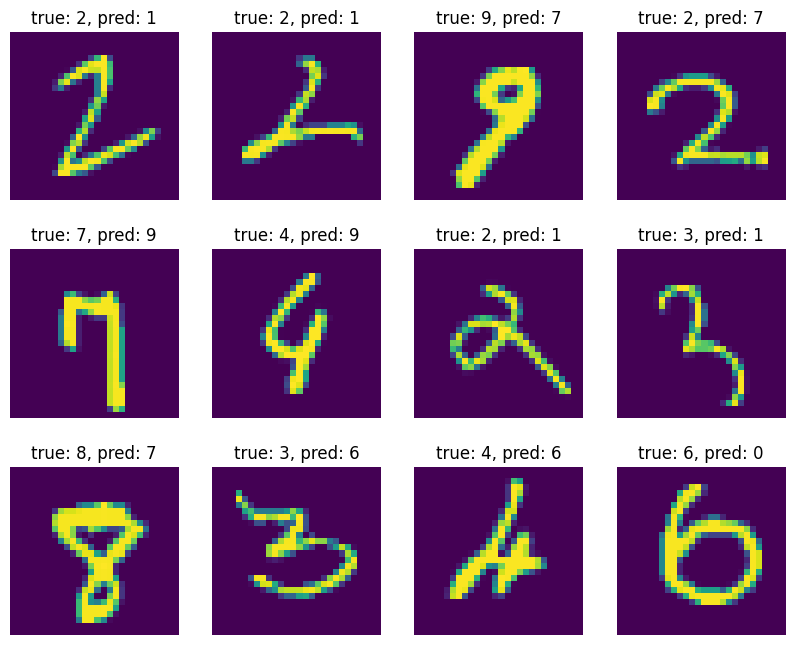

In [ ]:
#3rd part _ misclassified digits


mis_idx = np.where(test_pred != digits_test)[0]

# some mistakes
rows, cols = 3, 4
fig, axes = plt.subplots(rows, cols, figsize=(10,8))

for i, ax in enumerate(axes.flat):
  idx = mis_idx[i]
  ax.imshow(images_test[idx].reshape(28,28))
  ax.set_title(f"true: {digits_test[idx]}, pred: {test_pred[idx]}")
  ax.axis('off')

In [ ]:
#change performance of algorithm by changing numver of k neighbours


k_values = [1, 3, 5, 7, 9, 15]
train_accs = []
test_accs = []

for k in k_values:
  kn = KNeighborsClassifier(n_neighbors=k)
  kn.fit(images_train, digits_train)

  train_accs.append(kn.score(images_train, digits_train))
  test_accs.append(kn.score(images_test, digits_test))

print("Train:", train_accs)
print("Test :", test_accs)


Train: [1.0, 0.98075, 0.97505, 0.9703, 0.9667, 0.95745]
Test : [0.9582, 0.9595, 0.9591, 0.9572, 0.9557, 0.9515]


https://colab.research.google.com/drive/1IGEeMmVTby3pusNbxkSLXSwTpAoJdytd?usp=sharing